In [1]:
import pandas as pd

df = pd.read_csv("creditcard_2023.csv")

df.head()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0
1,1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0
2,2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0
3,3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0
4,4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0


info about dataset

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568630 entries, 0 to 568629
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      568630 non-null  int64  
 1   V1      568630 non-null  float64
 2   V2      568630 non-null  float64
 3   V3      568630 non-null  float64
 4   V4      568630 non-null  float64
 5   V5      568630 non-null  float64
 6   V6      568630 non-null  float64
 7   V7      568630 non-null  float64
 8   V8      568630 non-null  float64
 9   V9      568630 non-null  float64
 10  V10     568630 non-null  float64
 11  V11     568630 non-null  float64
 12  V12     568630 non-null  float64
 13  V13     568630 non-null  float64
 14  V14     568630 non-null  float64
 15  V15     568630 non-null  float64
 16  V16     568630 non-null  float64
 17  V17     568630 non-null  float64
 18  V18     568630 non-null  float64
 19  V19     568630 non-null  float64
 20  V20     568630 non-null  float64
 21  V21     56

In [3]:
df = df.drop('id', axis=1)

### Data Cleaning Conclusion

- No missing values ✅
- Correct data types ✅
- No immediate cleaning required ✅
- Dataset is large and suitable for ML ✅

⚠️ Note:
- 'id' column will be dropped later as it is not useful for prediction

In [4]:
df['Class'].value_counts()

Class
0    284315
1    284315
Name: count, dtype: int64

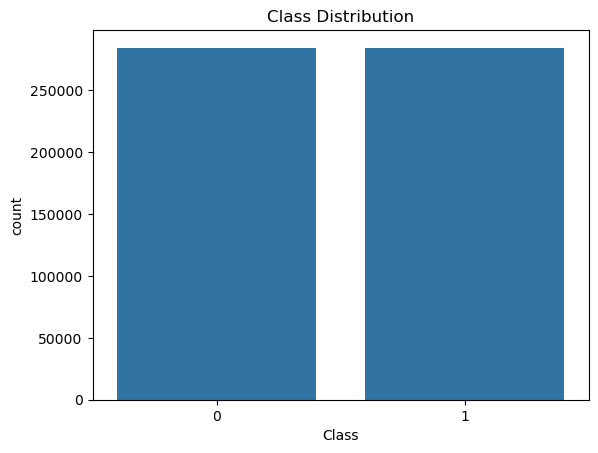

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Class', data=df)
plt.title("Class Distribution")
plt.show()

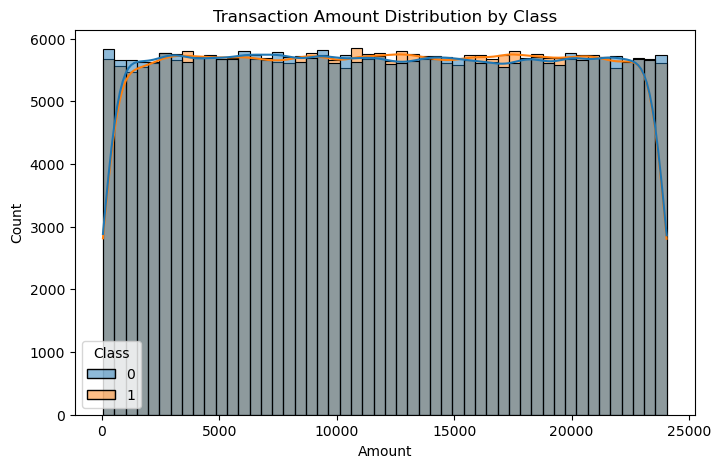

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Amount', hue='Class', bins=50, kde=True)
plt.title("Transaction Amount Distribution by Class")
plt.show()

### EDA - Transaction Amount

1. Do fraud and normal transactions have similar distributions?
   Yes, both distributions are almost identical and highly overlapping.

2. Do you see fraud more in high or low amounts?
   No clear pattern. Fraud transactions are spread across all amount ranges.

3. Is 'Amount' a useful feature for detecting fraud?
   Not very useful alone, as it does not clearly distinguish between fraud and normal transactions.

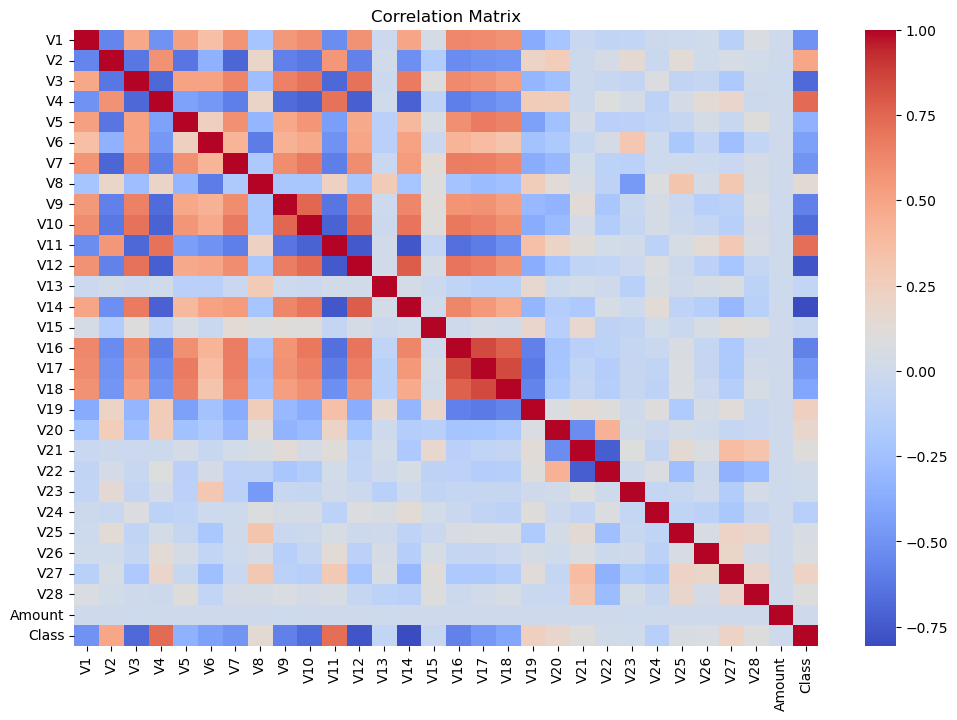

In [7]:
corr = df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

“Which features are MOST related to fraud?”

In [8]:
corr_with_target = df.corr()['Class'].sort_values(ascending=False)
corr_with_target[1:11]


V4     0.735981
V11    0.724278
V2     0.491878
V19    0.244081
V27    0.214002
V20    0.179851
V8     0.144294
V21    0.109640
V28    0.102024
V26    0.071052
Name: Class, dtype: float64

“Feature correlation analysis showed that variables like V4 and V11 have strong relationships with fraud. However, since the data is PCA-transformed, individual feature interpretation is limited, and fraud detection depends on combined feature interactions.”

“How do important features behave for fraud vs normal?”

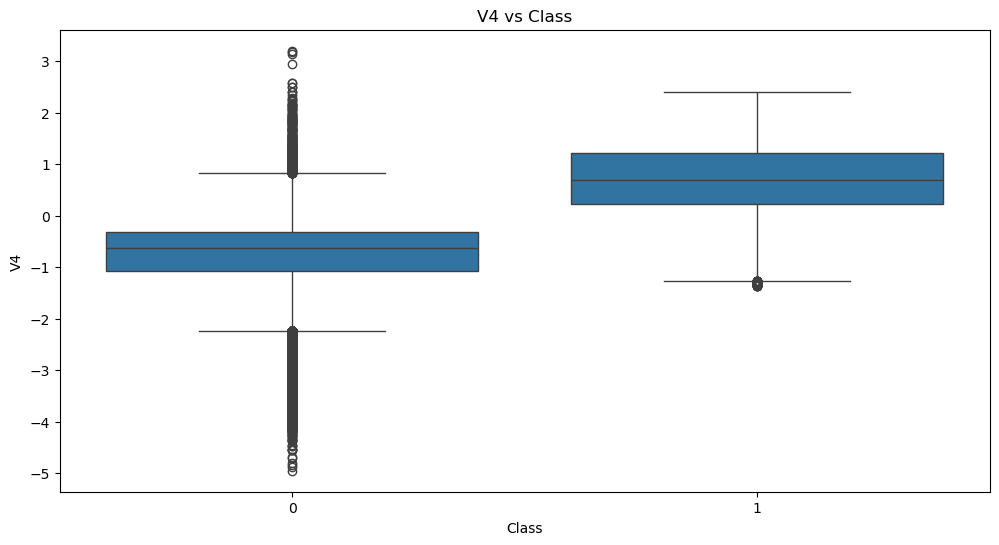

In [9]:
plt.figure(figsize=(12,6))

sns.boxplot(x='Class', y='V4', data=df)
plt.title("V4 vs Class")
plt.show()

“Boxplot analysis of V4 showed clear separation between fraud and normal transactions, indicating it is a strong predictive feature.”

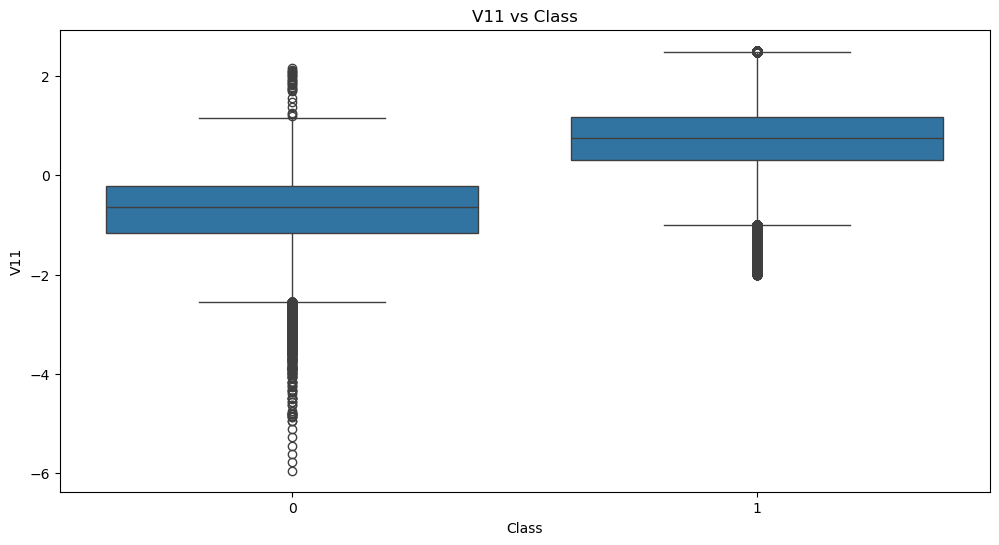

In [10]:
plt.figure(figsize=(12,6))

sns.boxplot(x='Class', y='V11', data=df)
plt.title("V11 vs Class")
plt.show()

“Boxplot analysis of V11 showed strong separation between fraud and normal transactions, indicating it is one of the most important predictive features.”

### Hypothesis Testing (V4 Feature)

Null Hypothesis (H0):
There is NO difference in V4 between fraud and normal transactions.

Alternative Hypothesis (H1):
There IS a difference in V4 between fraud and normal transactions.

In [11]:
from scipy.stats import ttest_ind 
fraud = df[df['Class'] == 1]['V4']
normal = df[df['Class'] == 0]['V4']

t_stat, p_value = ttest_ind(fraud, normal)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: 819.767061037011
P-Value: 0.0


“I validated feature importance using hypothesis testing. For V4, the p-value was effectively zero, confirming a statistically significant difference between fraud and normal transactions.”

In [12]:
fraud = df[df['Class'] == 1]['V11']
normal = df[df['Class'] == 0]['V11']

t_stat, p_value = ttest_ind(fraud, normal)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: 792.1004478661719
P-Value: 0.0


Feature Scaling + ML Preparation

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['Amount'] = scaler.fit_transform(df[['Amount']])

Now Split Data

In [14]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### Logistic Regression

1. Did the model train successfully?
   Yes, the model trained successfully.

2. Any warnings or errors?
   No errors were shown.

3. Why do we start with a simple model?
   To establish a baseline performance and then improve using more complex models.

“Given new unseen data, can you predict fraud or not?”

In [16]:
y_pred = model.predict(X_test)

In [17]:
print(y_pred[:10])

[1 1 0 1 1 0 1 1 0 1]


# Step 7: Model Evaluation

In this step, we evaluate how well our model performs on unseen data.

We use:
- Confusion Matrix
- Classification Report

This helps us understand:
- Correct predictions
- Errors made by the model
- Performance metrics (Precision, Recall, F1-score)

In [18]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[55493  1257]
 [ 2699 54277]]
              precision    recall  f1-score   support

           0       0.95      0.98      0.97     56750
           1       0.98      0.95      0.96     56976

    accuracy                           0.97    113726
   macro avg       0.97      0.97      0.97    113726
weighted avg       0.97      0.97      0.97    113726



### Model Evaluation

1. What is the accuracy?
   The model achieved approximately 97% accuracy.

2. What is precision (fraud class)?
   Precision is 0.98, meaning most predicted frauds are correct.

3. What is recall (fraud class)?
   Recall is 0.95, meaning 95% of fraud cases are detected.

4. Are there many false negatives?
   There are 2,699 false negatives, meaning some fraud cases were missed.

5. Which is more important and why?
   Recall is more important because missing fraud transactions leads to financial loss.

Confusion Matrix (Graph)

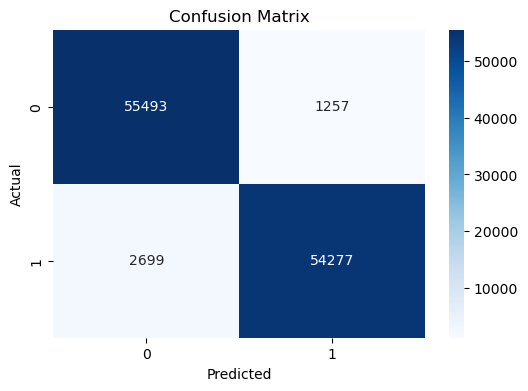

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Precision vs Recall Bar Chart

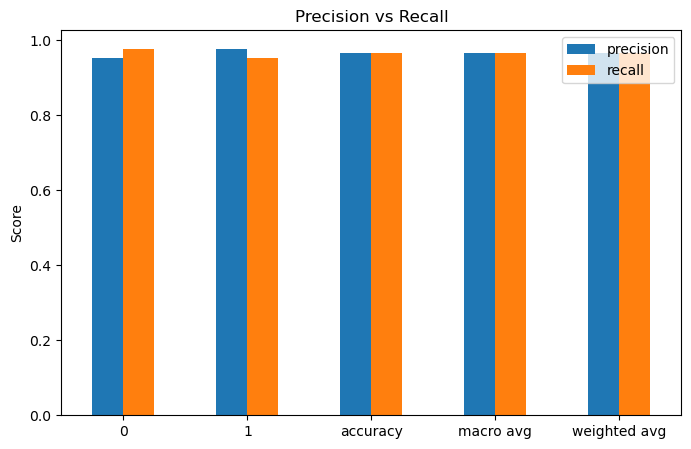

In [20]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

df_report[['precision', 'recall']].plot(kind='bar', figsize=(8,5))

plt.title("Precision vs Recall")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

“The model demonstrates higher precision than recall for the fraud class, indicating reliable fraud predictions but some missed fraud cases. In real-world fraud detection, improving recall would be critical to minimize financial losses.”

ROC Curve (Industry Level)

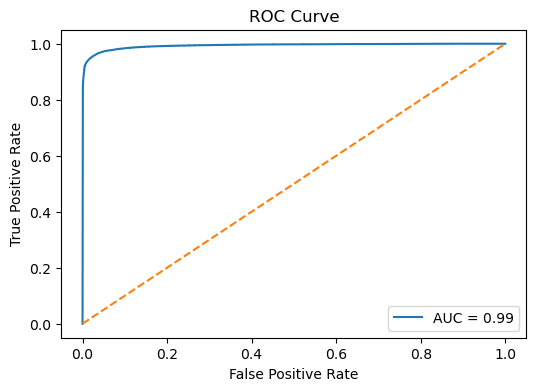

In [21]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

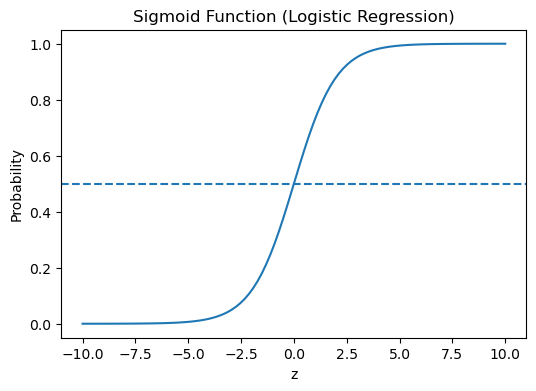

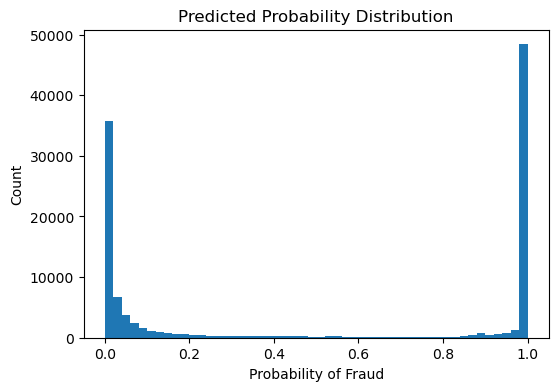

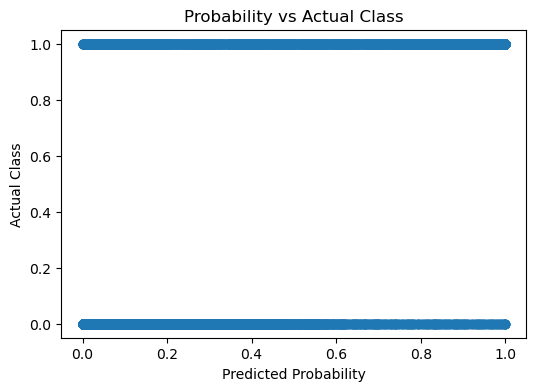

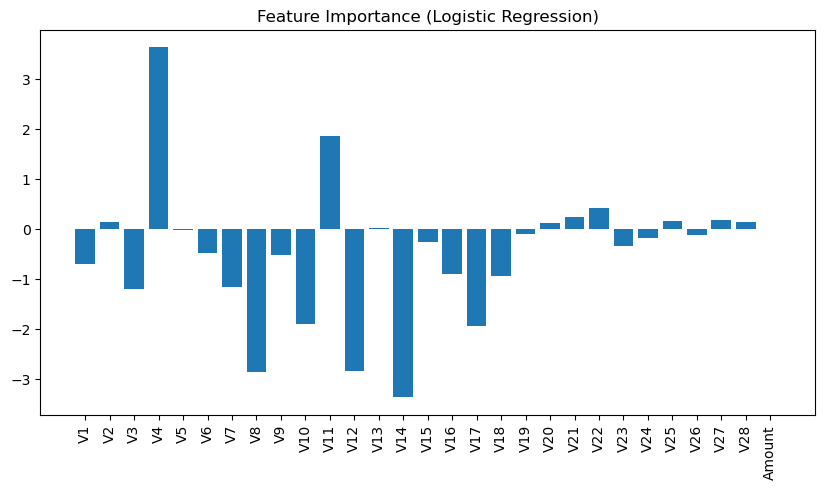

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ==============================
# 1. Sigmoid Function
# ==============================
z = np.linspace(-10, 10, 100)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(6,4))
plt.plot(z, sigmoid)
plt.axhline(0.5, linestyle='--')
plt.title("Sigmoid Function (Logistic Regression)")
plt.xlabel("z")
plt.ylabel("Probability")
plt.show()


# ==============================
# 2. Probability Distribution
# ==============================
y_prob = model.predict_proba(X_test)[:,1]

plt.figure(figsize=(6,4))
plt.hist(y_prob, bins=50)
plt.title("Predicted Probability Distribution")
plt.xlabel("Probability of Fraud")
plt.ylabel("Count")
plt.show()


# ==============================
# 3. Probability vs Actual
# ==============================
df_plot = pd.DataFrame({
    'Actual': y_test.values,
    'Probability': y_prob
})

plt.figure(figsize=(6,4))
plt.scatter(df_plot['Probability'], df_plot['Actual'], alpha=0.3)
plt.title("Probability vs Actual Class")
plt.xlabel("Predicted Probability")
plt.ylabel("Actual Class")
plt.show()


# ==============================
# 4. Feature Importance
# ==============================
importance = model.coef_[0]
feature_names = X.columns

plt.figure(figsize=(10,5))
plt.bar(feature_names, importance)
plt.xticks(rotation=90)
plt.title("Feature Importance (Logistic Regression)")
plt.show()

### Logistic Regression Visualization Insights

- The sigmoid function shows how logistic regression converts input into probability with a decision boundary at 0.5
- The probability distribution shows most predictions are near 0 or 1, indicating strong confidence
- The probability vs actual plot shows good separation between fraud and normal transactions, with minimal overlap
- Feature importance shows which variables contribute positively or negatively to fraud prediction

Key Insight:
The model is highly confident and effectively separates fraud from normal transactions, confirming earlier statistical findings.

# Step 8: Random Forest Model

We train a more powerful model to improve performance.

Model:
- Random Forest (Ensemble method)

Why?
- Captures complex patterns
- Handles non-linearity better than Logistic Regression

In [23]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=20,   # reduce trees
    max_depth=10,      # limit depth
    random_state=42,
    n_jobs=-1          # use all CPU cores
)

rf_model.fit(X_train, y_train)

,n_estimators,20
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Prediction

In [25]:
rf_model.fit(X_train, y_train)   # Train

y_pred_rf = rf_model.predict(X_test)   # Predict

print(confusion_matrix(y_test, y_pred_rf))   # Evaluate

[[56672    78]
 [ 1838 55138]]


In [26]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[56672    78]
 [ 1838 55138]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     56750
           1       1.00      0.97      0.98     56976

    accuracy                           0.98    113726
   macro avg       0.98      0.98      0.98    113726
weighted avg       0.98      0.98      0.98    113726



Confusion Matrix (Graph)

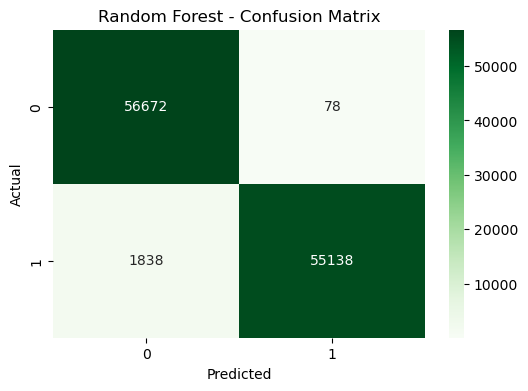

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

 ROC Curve

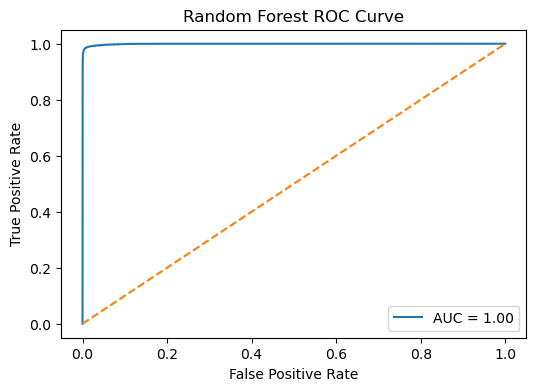

In [28]:
from sklearn.metrics import roc_curve, auc

y_prob_rf = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.title("Random Forest ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

The Random Forest model significantly outperformed Logistic Regression, achieving an accuracy of 98% with excellent precision and recall. The confusion matrix shows very few false positives, indicating reliable fraud predictions, while the recall of 0.97 demonstrates that most fraud cases are successfully detected. However, some false negatives still exist, meaning a small number of fraud transactions are missed, which is critical in real-world applications.

The ROC curve indicates near-perfect classification performance with an AUC close to 1. Feature importance analysis highlights key variables such as V14, V10, and V4 as major contributors, aligning with earlier exploratory analysis. Overall, the model is highly effective but can be further optimized to improve recall and minimize missed fraud cases.

Feature Importance

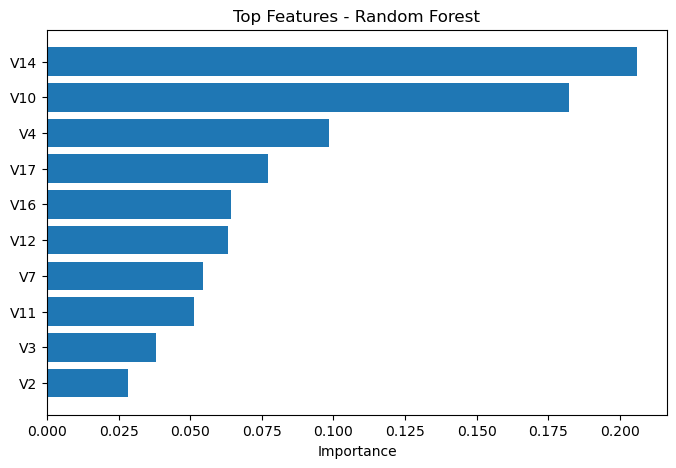

In [29]:
import pandas as pd

importances = rf_model.feature_importances_
features = X.columns

df_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
plt.barh(df_imp['Feature'][:10], df_imp['Importance'][:10])
plt.gca().invert_yaxis()

plt.title("Top Features - Random Forest")
plt.xlabel("Importance")

plt.show()

Feature importance analysis from the Random Forest model shows that a small number of features, particularly V14 and V10, contribute significantly to fraud detection. This indicates that the model relies heavily on specific patterns within the data. Additionally, features such as V4 and V11, which were identified during exploratory data analysis, are also among the top contributors, validating the earlier findings.

Lower-ranked features contribute less to the model’s predictions and could potentially be removed to simplify the model. Overall, the model demonstrates that fraud detection is driven by a combination of strong key features and supporting variables.

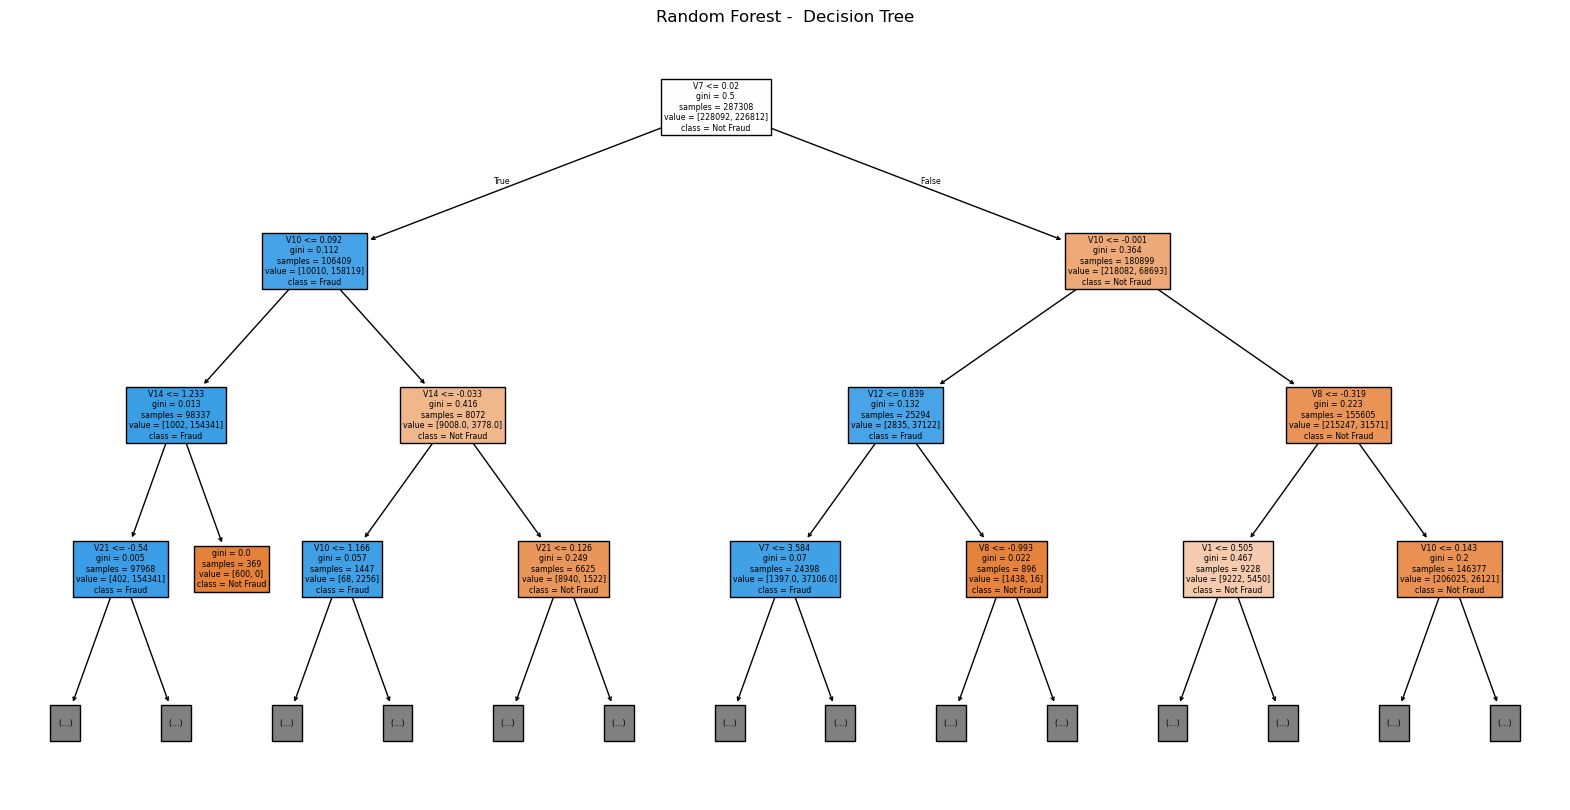

In [33]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Select ONE tree from the forest
tree = rf_model.estimators_[0]

plt.figure(figsize=(20,10))
plot_tree(tree, 
          feature_names=X.columns, 
          class_names=["Not Fraud", "Fraud"],
          filled=True,
          max_depth=3)   # limit depth for readability

plt.title("Random Forest -  Decision Tree")
plt.show()

“I visualized an individual tree from the Random Forest to understand decision logic. Each node represents a split based on a feature, and the model learns hierarchical rules to classify transactions. While a single tree is interpretable, Random Forest combines multiple trees to improve accuracy and reduce overfitting.”

MODEL OPTIMIZATION

In [30]:
# Get probabilities instead of 0/1
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Change threshold
threshold = 0.3   # try 0.3 instead of 0.5

y_pred_new = (y_prob_rf >= threshold).astype(int)

# Evaluate again
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_new))
print(classification_report(y_test, y_pred_new))

[[56069   681]
 [  680 56296]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     56750
           1       0.99      0.99      0.99     56976

    accuracy                           0.99    113726
   macro avg       0.99      0.99      0.99    113726
weighted avg       0.99      0.99      0.99    113726



                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.965215   0.977365  0.952629  0.964839
1        Random Forest  0.983152   0.998587  0.967741  0.982922
2   Threshold Tuned RF  0.988033   0.988048  0.988065  0.988056


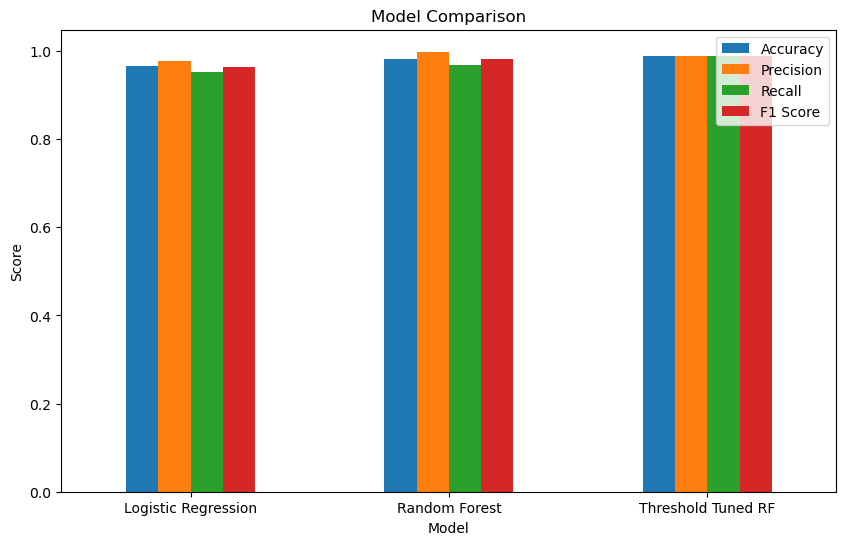

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Logistic Regression metrics
lr_acc = accuracy_score(y_test, y_pred)
lr_prec = precision_score(y_test, y_pred)
lr_rec = recall_score(y_test, y_pred)
lr_f1 = f1_score(y_test, y_pred)

# Random Forest metrics
rf_acc = accuracy_score(y_test, y_pred_rf)
rf_prec = precision_score(y_test, y_pred_rf)
rf_rec = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

# Threshold Tuned RF metrics
tuned_acc = accuracy_score(y_test, y_pred_new)
tuned_prec = precision_score(y_test, y_pred_new)
tuned_rec = recall_score(y_test, y_pred_new)
tuned_f1 = f1_score(y_test, y_pred_new)

# Create comparison table
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Threshold Tuned RF"],
    "Accuracy": [lr_acc, rf_acc, tuned_acc],
    "Precision": [lr_prec, rf_prec, tuned_prec],
    "Recall": [lr_rec, rf_rec, tuned_rec],
    "F1 Score": [lr_f1, rf_f1, tuned_f1]
})

print(comparison)
comparison.set_index("Model").plot(kind="bar", figsize=(10,6))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()